# 10 · Certify a small nonlinear system

**Time:** 100–120 minutes. **Preparation:** Lectures 08–09, 2×2 matrices, vector norms. **Lab:** [A two-dimensional Krawczyk test](../labs/lab10_nonlinear_systems.ipynb).

Objectives: enclose a Jacobian, use an approximate inverse as a proposal, and verify a local root with a contraction argument. Exhaustive search in two dimensions is an extension; this notebook certifies specified boxes.

## Google Colab setup — run this cell first

**Local Jupyter:** this cell skips Colab setup; use your installed course environment.

Use a **CPU Python runtime** (Python 3.12 or newer). Run the next cell and select
**vc_runtime.zip** from this edition when prompted. It loads the course helpers
and installs the arithmetic libraries. Repeat setup whenever you get a new runtime.
No Drive mounting or local Python installation is required.
Use this setup instead of the local installation and kernel-selection instructions
in the original course text.

Save a copy of this notebook in Drive, or download it after editing. Files created
by the project are under `/content/validated-course/build/certificates/`; download
those separately from Colab's Files panel. Runtime files are temporary.

Open other course notebooks using **File → Upload notebook**, choosing them from
the extracted course folder. Relative course links are intended for local Jupyter
and do not open sibling notebooks automatically in Colab. In labs, complete exercise
cells before running their diagnostics: `NotImplementedError` marks an unfinished task.


In [1]:
try:
    import google.colab
except ImportError:
    print("Local Jupyter: using the installed course environment.")
else:
    import hashlib
    from pathlib import Path
    import subprocess
    import sys
    from google.colab import files

    if sys.version_info < (3, 12):
        raise RuntimeError("This course needs a Python 3.12 or newer Colab runtime.")

    # Upload the small companion file supplied with the Colab course edition.
    expected_hash = '833652c4a440f1c3a22bc6e68c59d533b41e6f9f1ff0b4af226f8fbee2244c1a'
    runtime_zip = Path("/content") / ("vc-course-" + expected_hash + ".zip")
    if not runtime_zip.exists():
        print("Select vc_runtime.zip from the extracted Colab course folder.")
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError("Upload only vc_runtime.zip, then run this cell again.")
        archive_bytes = next(iter(uploaded.values()))
        if hashlib.sha256(archive_bytes).hexdigest() != expected_hash:
            raise ValueError("Wrong vc_runtime.zip: use the one supplied with this notebook.")
        runtime_zip.write_bytes(archive_bytes)

    if hashlib.sha256(runtime_zip.read_bytes()).hexdigest() != expected_hash:
        raise ValueError("The cached vc archive has changed; start a fresh runtime.")

    # Keep Colab's existing NumPy and plotting stack when they satisfy these bounds.
    # Install MPFR/Arb bindings, not the full local Jupyter environment.
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        'numpy>=1.26', 'matplotlib>=3.8', 'gmpy2==2.3.1', 'python-flint==0.9.0', 'jupytext>=1.16'
    ])
    import gmpy2
    import flint
    if gmpy2.version() != "2.3.1" or flint.__version__ != "0.9.0":
        raise RuntimeError("Old arithmetic libraries are still loaded. Restart the session and run setup first.")

    if str(runtime_zip) not in sys.path:
        sys.path.insert(0, str(runtime_zip))

    import vc
    if not vc.__file__.startswith(str(runtime_zip) + "/"):
        raise RuntimeError("Another vc copy is already loaded. Start a fresh runtime.")

    # Preserve the relative output paths used by the project notebooks.
    import os
    working_folder = Path("/content/validated-course") / 'notebooks'
    working_folder.mkdir(parents=True, exist_ok=True)
    os.chdir(working_folder)
    print("Course helpers ready:", vc.__version__)

Local Jupyter: using the installed course environment.


In [2]:
from fractions import Fraction
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display
from vc.intervals import RationalInterval as Interval
from vc.autodiff import jacobian2
from vc.systems import krawczyk, midpoint_inverse

def system(x, y):
    return [x*x+y*y-1, x-y]

def jacobian(box):
    return jacobian2(system, box)

## Motivation · A circle and a line

The equations x²+y²=1 and x=y have solutions (±1/√2, ±1/√2), with matching signs. Algebra supplies an independent check today. For a less convenient system, numerical iteration could supply a candidate.

A box X is a Cartesian product of two intervals. Its midpoint m has two exact rational coordinates. A matrix J(X) encloses each Jacobian entry throughout X. Matrix products below use interval addition and multiplication, with no unverified floating-point endpoints.

In [3]:
box = [Interval("0.7", "0.72"), Interval("0.7", "0.72")]
J = jacobian(box)
print("Jacobian enclosure:")
for row in J:
    print(row)
R = midpoint_inverse(J)
print("Point preconditioner:", R)

Jacobian enclosure:
[[7/5, 36/25], [7/5, 36/25]]
[[1, 1], [-1, -1]]
Point preconditioner: [[Fraction(25, 71), Fraction(1, 2)], [Fraction(25, 71), Fraction(-1, 2)]]


## THEORY · Turn roots into fixed points

Assume f is C¹ on a neighborhood of X. Choose a fixed nonsingular real 2×2 matrix R, usually near the inverse Jacobian at the midpoint. Define T(x)=x−R f(x). Then T(x)=x exactly when f(x)=0, because R is nonsingular.

Let E=I−R J(X). Applying the fundamental theorem of calculus along the line from m to x gives a Jacobian average with each entry in J(X). Hence

$$T(X)\subseteq K(X)=m-RF(m)+E(X-m).$$

This is the Krawczyk enclosure used here. `F(m)` encloses the vector f(m). Products may overestimate, but they preserve inclusion. Every root in X is a fixed point and must lie in K(X), so disjointness in even one coordinate excludes all roots in X.

## THEORY · An explicit sufficient contraction test

Assume f is C¹ on a neighborhood of the closed box X, and J(X) is a valid Jacobian enclosure. Define

$$q=\max_i\sum_j\max(|\underline E_{ij}|,|\overline E_{ij}|).$$

This bounds the infinity norm of T′ throughout X. If **K(X) is strictly inside X and q<1**, T maps X into itself and is a contraction. Banach's theorem gives a unique fixed point in X; nonsingular R makes it a root of f. Its coordinates also lie in K(X).

**Proof sketch of the fixed-point step:** successive iterates have distances bounded by qⁿ times the first distance. The resulting geometric series makes them Cauchy in the closed box. Their limit is a fixed point by continuity. Two fixed points u,v would satisfy ‖u−v‖∞≤q‖u−v‖∞, forcing equality u=v.

We check both conditions explicitly. This sufficient test is conservative; stronger Krawczyk theorems can succeed when this particular norm bound fails.

In [4]:
certificate = krawczyk(system, jacobian, box, R)
print("I - R*J(X):")
for row in certificate.remainder:
    print(row)
print("q =", certificate.contraction_bound)
print("K(X) =", certificate.image)
print("Status:", certificate.status)
assert certificate.status == "unique_root"
assert certificate.contraction_bound < 1
for part in certificate.image:
    assert 2*part.lo**2 < 1 < 2*part.hi**2

I - R*J(X):
[[-1/142, 1/142], [-1/142, 1/142]]
[[-1/142, 1/142], [-1/142, 1/142]]
q = 1/71
K(X) = [[10039/14200, 10043/14200], [10039/14200, 10043/14200]]
Status: unique_root


Read [vc/systems.py](../vc/systems.py). Each matrix entry is built by a short loop. The result records the box, midpoint, point preconditioner, Jacobian, residual enclosure, remainder matrix, Krawczyk image, and contraction bound. These are the quantities needed to inspect the certificate.

**CHECKPOINT (10 minutes):** why is nonsingularity of R necessary to turn a fixed point into a root? What would happen with R=0?

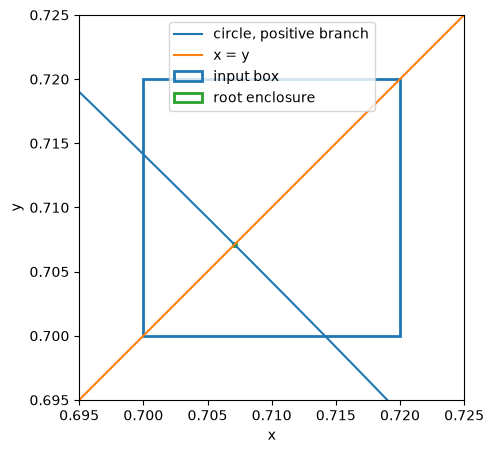

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
xs = np.linspace(0.69, 0.73, 201)
ax.plot(xs, np.sqrt(1-xs*xs), label="circle, positive branch")
ax.plot(xs, xs, label="x = y")
for parts, color, label in [(box, "tab:blue", "input box"),
                             (certificate.image, "tab:green", "root enclosure")]:
    rectangle = Rectangle((float(parts[0].lo), float(parts[1].lo)),
                          float(parts[0].width()), float(parts[1].width()),
                          fill=False, edgecolor=color, linewidth=2, label=label)
    ax.add_patch(rectangle)
ax.set(xlim=(0.695, 0.725), ylim=(0.695, 0.725), xlabel="x", ylabel="y")
ax.set_aspect("equal")
ax.legend()
display(fig)
plt.close(fig)

## EXPERIMENT · NumPy may propose R

An approximate inverse is allowed: the theorem does not require an exact inverse of the Jacobian. Convert each stored float entry explicitly to its exact binary rational value, then verify all inequalities using rigorous arithmetic. This certifies the chosen matrix's effect; it does not assume the inversion routine supplied a verified inverse.

In [6]:
midpoint_matrix = np.array([[float(entry.midpoint()) for entry in row] for row in J])
proposal = np.linalg.inv(midpoint_matrix)
R_from_numpy = []
for row in proposal:
    R_from_numpy.append([Fraction.from_float(float(entry)) for entry in row])
checked = krawczyk(system, jacobian, box, R_from_numpy)
print("Status with NumPy proposal:", checked.status)
assert checked.status == "unique_root"

Status with NumPy proposal: unique_root


## Failure case · Zero residual with a nearly singular Jacobian

Consider f(x,y)=(x+y, x+(1+ε)y+x²), ε=10⁻⁶. The origin has exactly zero residual, but so does (ε,−ε). A box containing both cannot have a valid uniqueness certificate. Its midpoint Jacobian has determinant ε; the large inverse amplifies the Jacobian variation.

In [7]:
epsilon = Fraction(1, 10**6)
def near_singular_system(x, y):
    return [x+y, x+(1+epsilon)*y+x*x]

def near_jacobian(box):
    return jacobian2(near_singular_system, box)

wide_box = [Interval("-1/100", "1/100"), Interval("-1/100", "1/100")]
R_near = midpoint_inverse(near_jacobian(wide_box))
failed = krawczyk(near_singular_system, near_jacobian, wide_box, R_near)
print("Residual at midpoint:", failed.residual)
print("q:", failed.contraction_bound, "status:", failed.status)
assert failed.status == "inconclusive"
assert near_singular_system(epsilon, -epsilon) == [0, 0]
assert near_singular_system(Fraction(0), Fraction(0)) == [0, 0]

Residual at midpoint: [[0, 0], [0, 0]]
q: 20000 status: inconclusive


## Local scope, exclusion, and reading

A successful test certifies one root in its specified box. It does not certify that no roots occur elsewhere. An inconclusive test means its sufficient conditions failed; that does not by itself prove absence or multiplicity. A disjoint Krawczyk image does prove exclusion under the stated premises.

**Exit ticket:** identify the rigorous checks after a NumPy proposal and explain the exact conclusion of each of the three statuses.

**Reading:** Tucker §5.1.5 (scalar Krawczyk), pp. 83–86, and Appendix A.4 (fixed-point theorems). For instructor background on multivariate verification, see S. M. Rump, [Verification methods: rigorous results using floating-point arithmetic](https://www.tuhh.de/ti3/rump/intlab/ActaNumerica2010.pdf), §13. Our explicit norm test above is a conservative teaching variant. Next: [global optimization](11_global_optimization.ipynb).